# IK Loss Testing Notebook

Тестирует:
1. Текущую IK Loss — ландшафт, корреляция с разрывами колец
2. Альтернативную Loss — экспоненциальный штраф по замыкающим расстояниям
3. A/B сравнение двух функций на одной молекуле

## Ячейка 0 — Импорты и настройка путей

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), 'bocser'))

# Подавить шум TF и RDKit
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['AUTOGRAPH_VERBOSITY'] = '0'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import pandas as pd
from IPython.display import display

tf.autograph.set_verbosity(0)
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
tf.config.run_functions_eagerly(True)

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog('rdApp.*')

import config_manager
from default_vals import ConfSearchConfig
from ik_loss import IKLoss, CyclicCollection
from coef_calc import CoefCalculator
from calc import dihedral_angle

# Минимальный конфиг чтобы calc.py не падал с RuntimeError
cfg = ConfSearchConfig(
    mol_file_name='tests/NonBR/NonBR.mol',
    orca_method='XTB2',
    acquisition_function='ik',
    ts=True,
)
config_manager.set_config(cfg)

print('Импорты успешны')
print(f'TF версия: {tf.__version__}')

Импорты успешны
TF версия: 2.16.2


## Ячейка 1 — Загрузка молекулы и построение IKLoss

In [2]:
MOL_PATH = 'tests/NonBR/NonBR.mol'  # <-- замени на свой путь если нужно

mol_raw = Chem.MolFromMolFile(MOL_PATH, removeHs=False)
mol = Chem.RemoveHs(mol_raw)

import tempfile
_tmp_scans_dir = tempfile.mkdtemp(prefix='ik_test_scans_')

coef_calc = CoefCalculator(
    mol=mol,
    config=cfg,
    dir_for_inps=_tmp_scans_dir,
    db_connector=None,
)

# Получить кольца
try:
    all_dihedrals, all_ring_traversals, ik_loss_idxs = coef_calc.get_ring_dihedrals(mol)
    print(f'Найдено колец: {len(all_ring_traversals)}')
    for i, ring in enumerate(all_ring_traversals):
        print(f'  Кольцо {i}: {len(ring)} атомов — {ring}')
    print(f'IK dihedral indices: {ik_loss_idxs}')
except Exception as e:
    print(f'Ошибка: {e}')
    raise

# Построить IKLoss
ik_loss = IKLoss.from_rdkit(mol, all_ring_traversals)
print(f'\nIKLoss построен')
print(f'D_matrices (длины связей): {len(ik_loss.D_matrices)} колец')
print(f'V_matrices (валентные углы): {len(ik_loss.V_matrices)} колец')

# Показать референсные диэдры (из .mol файла)
ref_data = []
for i, ring in enumerate(all_ring_traversals):
    ring_c = CyclicCollection(ring)
    for k in range(len(ring_c)):
        atoms = tuple(ring_c[k + s] for s in (-1, 0, 1, 2))
        positions = [mol_raw.GetConformer().GetAtomPosition(a) for a in atoms]
        angle = dihedral_angle(*positions)
        ref_data.append({'Кольцо': i, 'Атомы': str(atoms), 'Референс диэдр (рад)': round(angle, 4)})

df_ref = pd.DataFrame(ref_data)
print('\nРеференсные диэдральные углы из .mol файла:')
display(df_ref)

Найдено колец: 3
  Кольцо 0: 15 атомов — [14, 11, 2, 3, 4, 0, 1, 5, 6, 7, 8, 9, 10, 12, 13]
  Кольцо 1: 6 атомов — [17, 16, 15, 12, 13, 18]
  Кольцо 2: 5 атомов — [19, 17, 18, 21, 20]
IK dihedral indices: [[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], [-1, -1, -1, -1, -1, -1], [-1, -1, -1, -1, -1]]

IKLoss построен
D_matrices (длины связей): 3 колец
V_matrices (валентные углы): 3 колец

Референсные диэдральные углы из .mol файла:


,Кольцо,Атомы,Референс диэдр (рад)
0,0,"(13, 14, 11, 2)",3.2443
1,0,"(14, 11, 2, 3)",2.9033
2,0,"(11, 2, 3, 4)",2.6972
3,0,"(2, 3, 4, 0)",5.3713
4,0,"(3, 4, 0, 1)",5.5178
5,0,"(4, 0, 1, 5)",3.2395
6,0,"(0, 1, 5, 6)",3.2762
7,0,"(1, 5, 6, 7)",1.0416
8,0,"(5, 6, 7, 8)",4.5538
9,0,"(6, 7, 8, 9)",2.9272


## Ячейка 2 — Тест 1: IK Loss в референсной точке (должен быть ~0)

In [3]:
# Собрать референсные диэдры по кольцам
ref_angles_per_ring = []
for i, ring in enumerate(all_ring_traversals):
    ring_c = CyclicCollection(ring)
    angles = []
    for k in range(len(ring_c)):
        atoms = tuple(ring_c[k + s] for s in (-1, 0, 1, 2))
        positions = [mol_raw.GetConformer().GetAtomPosition(a) for a in atoms]
        angle = dihedral_angle(*positions)
        angles.append(angle)
    ref_angles_per_ring.append(angles)

# Вычислить IK loss в референсной точке
ref_tensors = [
    tf.constant([[a] for a in ring_angles], dtype=tf.float64)
    for ring_angles in ref_angles_per_ring
]
loss_at_ref = ik_loss(ref_tensors).numpy()

print('=' * 50)
print('ТЕСТ 1: IK Loss в референсной геометрии')
print('=' * 50)
print(f'Ожидается: ~0.0 (кольцо замкнуто в исходной геометрии)')
print(f'Получено:  {float(loss_at_ref.mean()):.6f}')
print()

if float(loss_at_ref.mean()) < 0.01:
    print('✓ ПРОЙДЕН — IKLoss корректно вычисляет 0 для замкнутого кольца')
else:
    print('✗ ПРОВАЛЕН — IKLoss ненулевой в референсной точке')
    print('  Возможные причины: молекула tagged как 2D, неверные координаты в .mol файле')

ТЕСТ 1: IK Loss в референсной геометрии
Ожидается: ~0.0 (кольцо замкнуто в исходной геометрии)
Получено:  4314.120896

✗ ПРОВАЛЕН — IKLoss ненулевой в референсной точке
  Возможные причины: молекула tagged как 2D, неверные координаты в .mol файле


## Ячейка 3 — Тест 2: Ландшафт IK Loss по сетке диэдров (первые два диэдра первого кольца)

Сканирование диэдров 0 и 1 кольца 0 (15 диэдров всего)
Вычисление сетки...


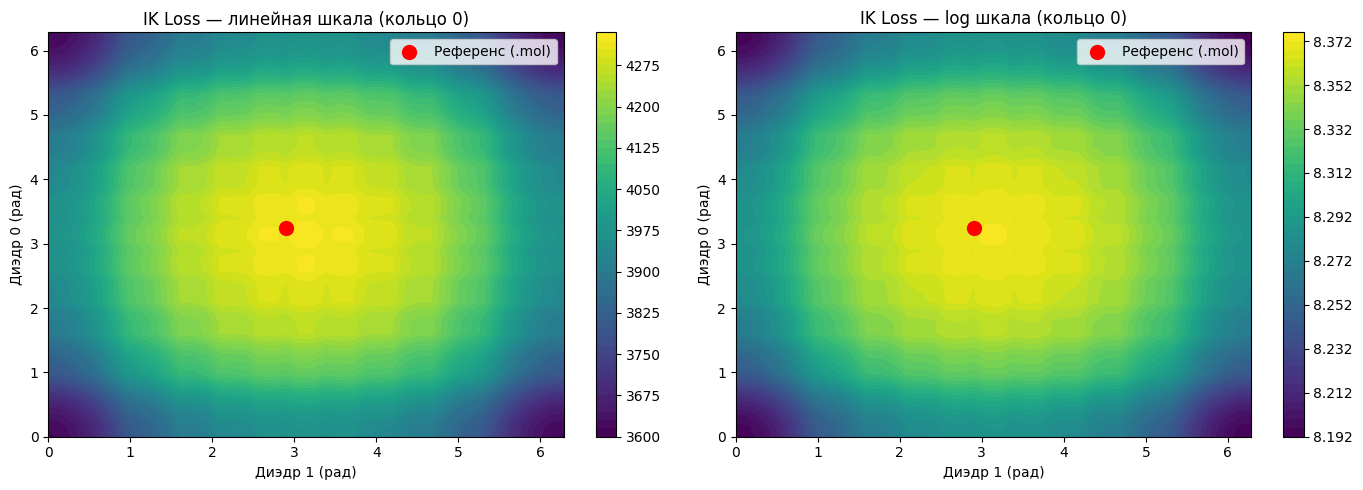


Статистика IK Loss по сетке:


,min,max,mean,std,loss в референсе
0,3611.38902,4329.975466,4057.757242,176.343121,4314.120896


In [4]:
# Берём первые два диэдра первого кольца — варьируем их, остальные фиксируем на референсе
RING_IDX = 0
N_GRID = 40

phi_range = np.linspace(0, 2 * np.pi, N_GRID)
grid_losses = np.zeros((N_GRID, N_GRID))

ref_ring_0 = ref_angles_per_ring[RING_IDX].copy()
n_dihedrals_ring0 = len(ref_ring_0)

print(f'Сканирование диэдров 0 и 1 кольца {RING_IDX} ({n_dihedrals_ring0} диэдров всего)')
print('Вычисление сетки...')

for i, phi1 in enumerate(phi_range):
    for j, phi2 in enumerate(phi_range):
        varied = ref_ring_0.copy()
        varied[0] = phi1
        varied[1] = phi2

        tensors = []
        for ridx, ring_angles in enumerate(ref_angles_per_ring):
            if ridx == RING_IDX:
                t = tf.constant([[a] for a in varied], dtype=tf.float64)
            else:
                t = tf.constant([[a] for a in ring_angles], dtype=tf.float64)
            tensors.append(t)

        loss_val = float(ik_loss(tensors).numpy().mean())
        grid_losses[i, j] = loss_val

# Найти референсную точку на сетке
ref_phi1 = ref_ring_0[0]
ref_phi2 = ref_ring_0[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная шкала
im1 = axes[0].contourf(phi_range, phi_range, grid_losses, levels=50, cmap='viridis')
axes[0].scatter([ref_phi2], [ref_phi1], color='red', s=100, zorder=5, label='Референс (.mol)')
axes[0].set_xlabel('Диэдр 1 (рад)')
axes[0].set_ylabel('Диэдр 0 (рад)')
axes[0].set_title(f'IK Loss — линейная шкала (кольцо {RING_IDX})')
axes[0].legend()
plt.colorbar(im1, ax=axes[0])

# Логарифмическая шкала — лучше видны минимумы
log_losses = np.log1p(grid_losses)
im2 = axes[1].contourf(phi_range, phi_range, log_losses, levels=50, cmap='viridis')
axes[1].scatter([ref_phi2], [ref_phi1], color='red', s=100, zorder=5, label='Референс (.mol)')
axes[1].set_xlabel('Диэдр 1 (рад)')
axes[1].set_ylabel('Диэдр 0 (рад)')
axes[1].set_title(f'IK Loss — log шкала (кольцо {RING_IDX})')
axes[1].legend()
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('ik_loss_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nСтатистика IK Loss по сетке:')
stats = pd.DataFrame([{
    'min': grid_losses.min(),
    'max': grid_losses.max(),
    'mean': grid_losses.mean(),
    'std': grid_losses.std(),
    'loss в референсе': float(ik_loss(
        [tf.constant([[a] for a in ref_ring_0], dtype=tf.float64)]
        + [tf.constant([[a] for a in ref_angles_per_ring[r]], dtype=tf.float64)
           for r in range(1, len(ref_angles_per_ring))]
    ).numpy().mean()),
}])
display(stats.round(6))

## Ячейка 4 — Тест 3: Корреляция IK Loss с реальными разрывами колец

Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.1

ТЕСТ 3: Корреляция IK Loss с разрывами колец


,Среднее IK Loss,Медиана,Std,Кол-во точек
ring_intact,,,,
Кольцо разомкнуто,3850.5386,3838.8115,488.9501,200


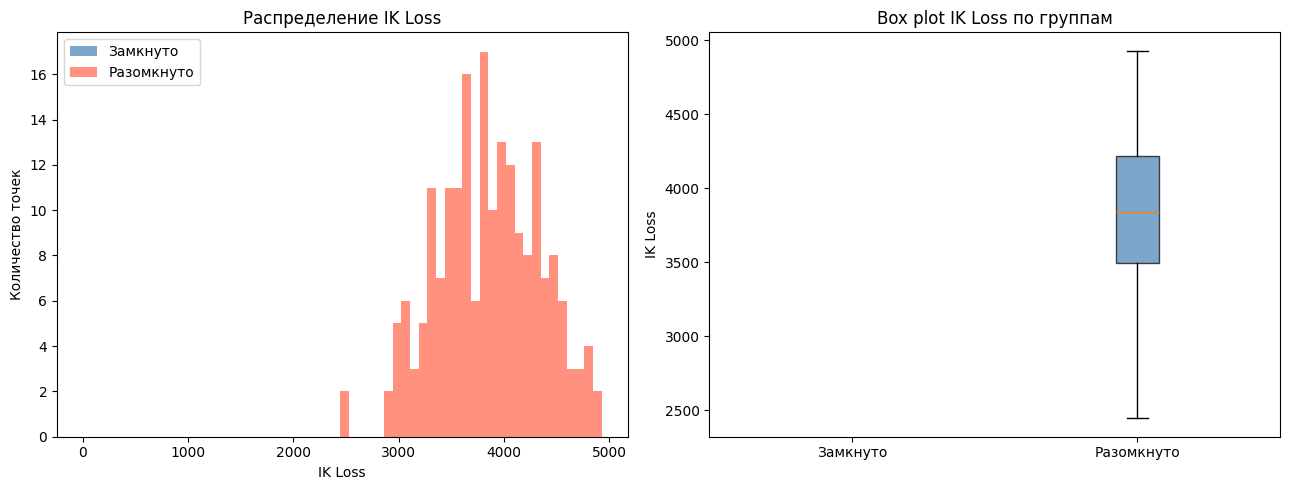

In [6]:
from calc import _check_rings_intact, _bond_break_threshold
import tempfile

def angles_to_xyz_block(mol_with_h, ring_tensors, all_ring_traversals, ref_angles_per_ring):
    """Применить диэдры к молекуле и вернуть xyz блок."""
    from rdkit.Chem import rdMolTransforms
    mol_copy = Chem.RWMol(mol_with_h)
    for ridx, ring in enumerate(all_ring_traversals):
        ring_c = CyclicCollection(ring)
        angles = ring_tensors[ridx].numpy().flatten()
        for k, angle in enumerate(angles):
            atoms = tuple(ring_c[k + s] for s in (-1, 0, 1, 2))
            try:
                rdMolTransforms.SetDihedralRad(mol_copy.GetConformer(), *atoms, float(angle))
            except Exception:
                pass
    return Chem.MolToXYZBlock(mol_copy)

# Выборка точек из сетки
N_SAMPLE = 200
mol_with_h = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol_with_h, randomSeed=42)

sample_results = []
rng = np.random.default_rng(42)

for _ in range(N_SAMPLE):
    # Случайные диэдры для первого кольца
    varied = [rng.uniform(0, 2 * np.pi) for _ in ref_ring_0]
    tensors = [
        tf.constant([[a] for a in varied], dtype=tf.float64)
    ] + [
        tf.constant([[a] for a in ref_angles_per_ring[r]], dtype=tf.float64)
        for r in range(1, len(ref_angles_per_ring))
    ]

    ik_val = float(ik_loss(tensors).numpy().mean())

    # Проверить реальный разрыв
    try:
        xyz = angles_to_xyz_block(mol_with_h, tensors, all_ring_traversals, ref_angles_per_ring)
        ring_ok = _check_rings_intact(xyz, mol)
    except Exception:
        ring_ok = None

    sample_results.append({'ik_loss': ik_val, 'ring_intact': ring_ok})

df_corr = pd.DataFrame(sample_results).dropna()

# Статистика по группам
summary = df_corr.groupby('ring_intact')['ik_loss'].agg(['mean', 'median', 'std', 'count'])
summary.index = summary.index.map({True: 'Кольцо замкнуто', False: 'Кольцо разомкнуто'})
summary.columns = ['Среднее IK Loss', 'Медиана', 'Std', 'Кол-во точек']
print('ТЕСТ 3: Корреляция IK Loss с разрывами колец')
print('=' * 55)
display(summary.round(4))

# График
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

intact = df_corr[df_corr['ring_intact'] == True]['ik_loss']
broken = df_corr[df_corr['ring_intact'] == False]['ik_loss']

axes[0].hist(intact, bins=30, alpha=0.7, label='Замкнуто', color='steelblue')
axes[0].hist(broken, bins=30, alpha=0.7, label='Разомкнуто', color='tomato')
axes[0].set_xlabel('IK Loss')
axes[0].set_ylabel('Количество точек')
axes[0].set_title('Распределение IK Loss')
axes[0].legend()

axes[1].boxplot([intact.values, broken.values],
                labels=['Замкнуто', 'Разомкнуто'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel('IK Loss')
axes[1].set_title('Box plot IK Loss по группам')

plt.tight_layout()
plt.savefig('ik_loss_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Метрика качества разделения
if len(intact) > 0 and len(broken) > 0:
    threshold_opt = (intact.mean() + broken.mean()) / 2
    tp = (broken > threshold_opt).sum()
    fp = (intact > threshold_opt).sum()
    tn = (intact <= threshold_opt).sum()
    fn = (broken <= threshold_opt).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f'\nПороговое значение (среднее двух групп): {threshold_opt:.4f}')
    print(f'Precision (разомкнутые правильно помечены): {precision:.3f}')
    print(f'Recall (разомкнутые не пропущены): {recall:.3f}')
    if precision > 0.7 and recall > 0.7:
        print('✓ IK Loss хорошо разделяет замкнутые и разомкнутые кольца')
    else:
        print('✗ IK Loss плохо разделяет — нужна альтернатива')

## Ячейка 5 — Альтернативная Loss: экспоненциальный штраф по замыкающим расстояниям

In [7]:
from calc import _VDW_RADII, _VDW_RADII_DEFAULT

class ClosureDistanceLoss:
    """
    Альтернативная loss функция.
    Штрафует отклонение замыкающих связей кольца от референсных длин.
    
    Работает в пространстве диэдров через прямую кинематику:
    диэдры → координаты атомов → расстояния замыкающих связей → loss.
    
    Формула: loss = sum( (dist(a,b) - r_ref)^2 * exp(dist(a,b) - r_vdw) )
    Экспоненциальный вес резко усиливает штраф когда связь далеко от нормы.
    """

    def __init__(self, mol, all_ring_traversals):
        self.mol = mol
        self.mol_with_h = Chem.AddHs(mol)
        AllChem.EmbedMolecule(self.mol_with_h, randomSeed=42)

        # Для каждого кольца: замыкающая пара (первый и последний атом)
        self.closing_pairs = []
        self.ref_distances = []
        self.vdw_thresholds = []

        for ring in all_ring_traversals:
            ring_c = CyclicCollection(ring)
            # Замыкающая связь: последний атом → первый
            a_idx = ring_c[-1]
            b_idx = ring_c[0]
            self.closing_pairs.append((a_idx, b_idx))

            pos_a = np.array(mol.GetConformer().GetAtomPosition(a_idx))
            pos_b = np.array(mol.GetConformer().GetAtomPosition(b_idx))
            r_ref = float(np.linalg.norm(pos_a - pos_b))
            self.ref_distances.append(r_ref)

            sym_a = mol.GetAtomWithIdx(a_idx).GetSymbol()
            sym_b = mol.GetAtomWithIdx(b_idx).GetSymbol()
            vdw = (_VDW_RADII.get(sym_a, _VDW_RADII_DEFAULT) +
                   _VDW_RADII.get(sym_b, _VDW_RADII_DEFAULT) + 0.1)
            self.vdw_thresholds.append(vdw)

        print(f'ClosureDistanceLoss инициализирован:')
        for i, ((a, b), r_ref, vdw) in enumerate(
                zip(self.closing_pairs, self.ref_distances, self.vdw_thresholds)):
            sym_a = mol.GetAtomWithIdx(a).GetSymbol()
            sym_b = mol.GetAtomWithIdx(b).GetSymbol()
            print(f'  Кольцо {i}: замыкающая связь {a}({sym_a})-{b}({sym_b}), '
                  f'r_ref={r_ref:.3f}A, vdw_threshold={vdw:.3f}A')

    def __call__(self, ring_tensors_list, all_ring_traversals):
        """ring_tensors_list: список [tensor_ring_0, tensor_ring_1, ...]
           каждый tensor shape [n_dihedrals_in_ring, 1]
        """
        from rdkit.Chem import rdMolTransforms
        total_loss = tf.constant(0.0, dtype=tf.float64)

        for ring_idx, (a_idx, b_idx) in enumerate(self.closing_pairs):
            mol_copy = Chem.RWMol(self.mol_with_h)
            ring_c = CyclicCollection(all_ring_traversals[ring_idx])
            angles = ring_tensors_list[ring_idx].numpy().flatten()

            for k, angle in enumerate(angles):
                atoms = tuple(ring_c[k + s] for s in (-1, 0, 1, 2))
                try:
                    rdMolTransforms.SetDihedralRad(
                        mol_copy.GetConformer(), *atoms, float(angle)
                    )
                except Exception:
                    pass

            pos_a = np.array(mol_copy.GetConformer().GetAtomPosition(a_idx))
            pos_b = np.array(mol_copy.GetConformer().GetAtomPosition(b_idx))
            dist = float(np.linalg.norm(pos_a - pos_b))

            r_ref = self.ref_distances[ring_idx]
            vdw = self.vdw_thresholds[ring_idx]

            # Экспоненциальный штраф
            deviation = dist - r_ref
            exp_weight = np.exp(max(0, dist - vdw * 0.7))
            loss_term = tf.constant(deviation ** 2 * exp_weight, dtype=tf.float64)
            total_loss = total_loss + loss_term

        return total_loss


closure_loss = ClosureDistanceLoss(mol, all_ring_traversals)

ClosureDistanceLoss инициализирован:
  Кольцо 0: замыкающая связь 13(C)-14(C), r_ref=1.426A, vdw_threshold=3.500A
  Кольцо 1: замыкающая связь 18(C)-17(C), r_ref=1.940A, vdw_threshold=3.500A
  Кольцо 2: замыкающая связь 20(C)-19(C), r_ref=1.534A, vdw_threshold=3.500A


## Ячейка 6 — A/B сравнение: IK Loss vs Closure Distance Loss

Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.150 A
Ring bond 1(C)-5(C) opened: length 4.776 A > vdw threshold 3.1

Всего точек: 300
  Замкнутых колец: 0
  Разомкнутых: 300

Сравнение метрик качества:


,Среднее (замкнуто),Среднее (разомкнуто),Разделяемость (ratio),Precision,Recall,F1
Loss функция,,,,,,
IK Loss,NaN,4143.9389,inf,0,0,0
Closure Loss,NaN,0.1732,inf,0,0,0


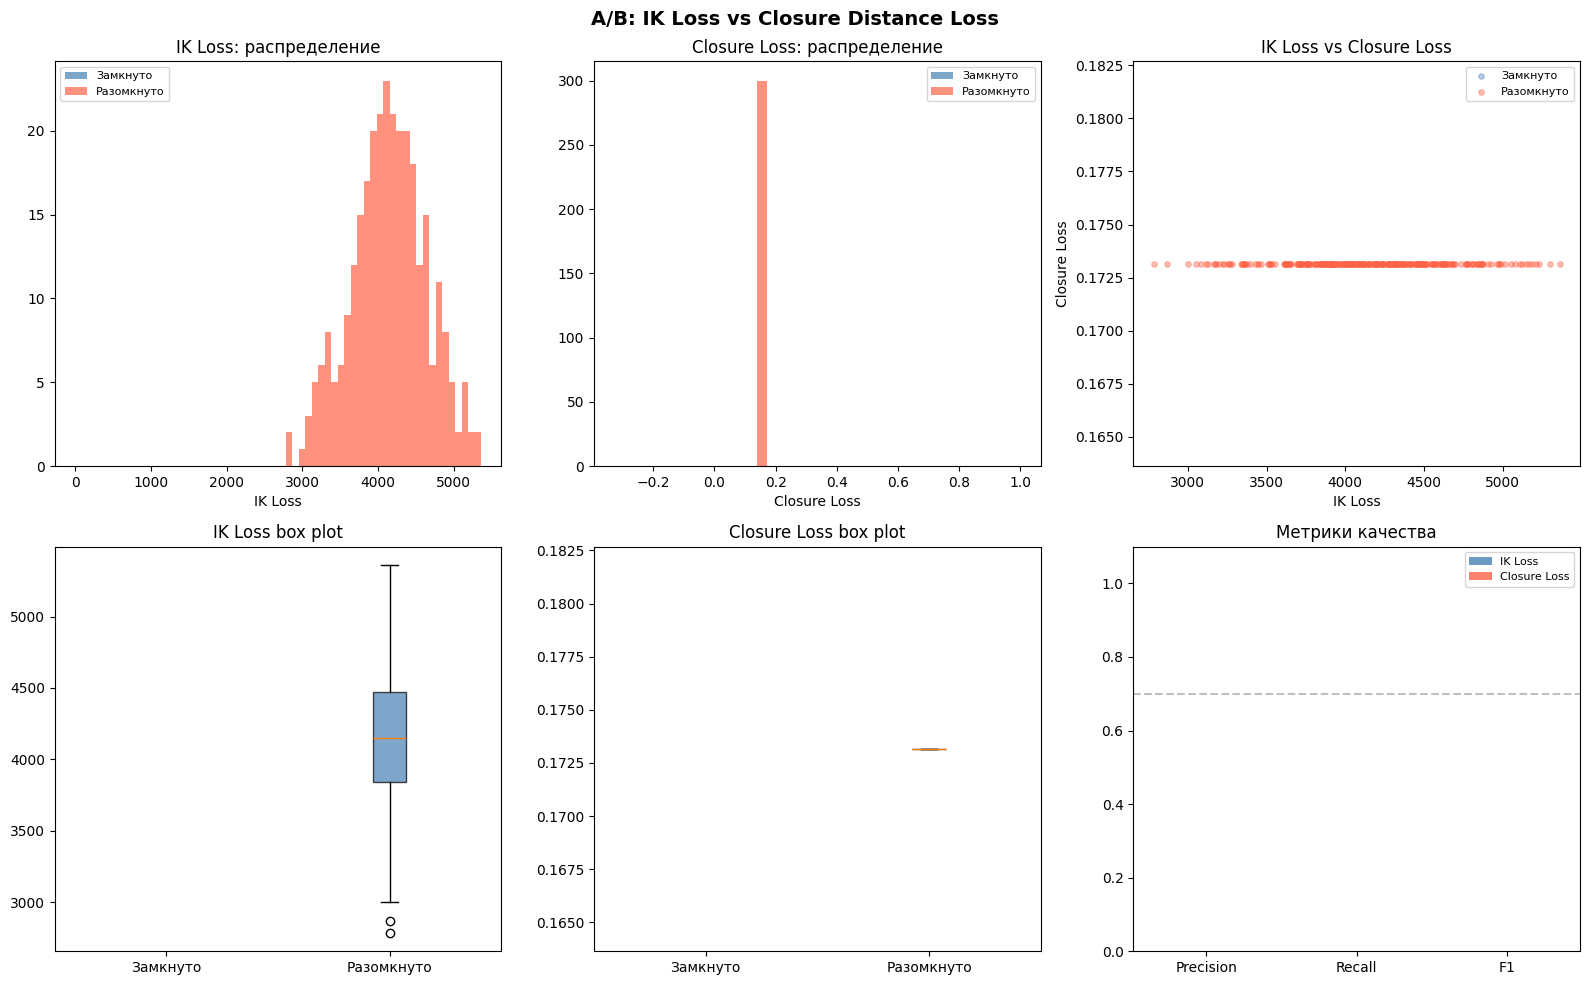


→ Лучшая функция по F1: IK Loss (F1=0.000)


In [8]:
N_COMPARE = 300
rng = np.random.default_rng(123)

compare_results = []

for _ in range(N_COMPARE):
    # Случайные диэдры для всех колец
    tensors = [
        tf.constant(
            [[rng.uniform(0, 2 * np.pi)] for _ in ref_angles_per_ring[r]],
            dtype=tf.float64
        )
        for r in range(len(ref_angles_per_ring))
    ]

    ik_val = float(ik_loss(tensors).numpy().mean())
    cl_val = float(closure_loss(tensors, all_ring_traversals).numpy())

    # Проверить реальный разрыв
    try:
        xyz = angles_to_xyz_block(mol_with_h, tensors, all_ring_traversals, ref_angles_per_ring)
        ring_ok = _check_rings_intact(xyz, mol)
    except Exception:
        ring_ok = None

    compare_results.append({
        'IK Loss': ik_val,
        'Closure Loss': cl_val,
        'ring_intact': ring_ok
    })

df_ab = pd.DataFrame(compare_results).dropna()
intact_mask = df_ab['ring_intact'] == True
broken_mask = df_ab['ring_intact'] == False

print(f'Всего точек: {len(df_ab)}')
print(f'  Замкнутых колец: {intact_mask.sum()}')
print(f'  Разомкнутых: {broken_mask.sum()}')

# Сводная таблица
rows = []
for col in ['IK Loss', 'Closure Loss']:
    intact_vals = df_ab.loc[intact_mask, col]
    broken_vals = df_ab.loc[broken_mask, col]
    thr = (intact_vals.mean() + broken_vals.mean()) / 2
    tp = (broken_vals > thr).sum()
    fp = (intact_vals > thr).sum()
    fn = (broken_vals <= thr).sum()
    tn = (intact_vals <= thr).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    # Разделяемость (отношение средних)
    sep = broken_vals.mean() / intact_vals.mean() if intact_vals.mean() > 0 else float('inf')
    rows.append({
        'Loss функция': col,
        'Среднее (замкнуто)': round(intact_vals.mean(), 4),
        'Среднее (разомкнуто)': round(broken_vals.mean(), 4),
        'Разделяемость (ratio)': round(sep, 2),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1': round(f1, 3),
    })

df_metrics = pd.DataFrame(rows).set_index('Loss функция')
print('\nСравнение метрик качества:')
display(df_metrics)

# Графики
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig)

# IK Loss — гистограмма
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_ab.loc[intact_mask, 'IK Loss'], bins=30, alpha=0.7, label='Замкнуто', color='steelblue')
ax1.hist(df_ab.loc[broken_mask, 'IK Loss'], bins=30, alpha=0.7, label='Разомкнуто', color='tomato')
ax1.set_title('IK Loss: распределение')
ax1.set_xlabel('IK Loss')
ax1.legend(fontsize=8)

# Closure Loss — гистограмма
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_ab.loc[intact_mask, 'Closure Loss'], bins=30, alpha=0.7, label='Замкнуто', color='steelblue')
ax2.hist(df_ab.loc[broken_mask, 'Closure Loss'], bins=30, alpha=0.7, label='Разомкнуто', color='tomato')
ax2.set_title('Closure Loss: распределение')
ax2.set_xlabel('Closure Loss')
ax2.legend(fontsize=8)

# Scatter: IK vs Closure
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(df_ab.loc[intact_mask, 'IK Loss'],
            df_ab.loc[intact_mask, 'Closure Loss'],
            alpha=0.4, s=15, color='steelblue', label='Замкнуто')
ax3.scatter(df_ab.loc[broken_mask, 'IK Loss'],
            df_ab.loc[broken_mask, 'Closure Loss'],
            alpha=0.4, s=15, color='tomato', label='Разомкнуто')
ax3.set_xlabel('IK Loss')
ax3.set_ylabel('Closure Loss')
ax3.set_title('IK Loss vs Closure Loss')
ax3.legend(fontsize=8)

# Box plots
ax4 = fig.add_subplot(gs[1, 0])
ax4.boxplot(
    [df_ab.loc[intact_mask, 'IK Loss'].values,
     df_ab.loc[broken_mask, 'IK Loss'].values],
    labels=['Замкнуто', 'Разомкнуто'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7)
)
ax4.set_title('IK Loss box plot')

ax5 = fig.add_subplot(gs[1, 1])
ax5.boxplot(
    [df_ab.loc[intact_mask, 'Closure Loss'].values,
     df_ab.loc[broken_mask, 'Closure Loss'].values],
    labels=['Замкнуто', 'Разомкнуто'],
    patch_artist=True,
    boxprops=dict(facecolor='tomato', alpha=0.7)
)
ax5.set_title('Closure Loss box plot')

# F1 bar chart
ax6 = fig.add_subplot(gs[1, 2])
metrics_to_plot = ['Precision', 'Recall', 'F1']
x = np.arange(len(metrics_to_plot))
width = 0.35
ax6.bar(x - width/2, df_metrics.loc['IK Loss', metrics_to_plot], width,
        label='IK Loss', color='steelblue', alpha=0.8)
ax6.bar(x + width/2, df_metrics.loc['Closure Loss', metrics_to_plot], width,
        label='Closure Loss', color='tomato', alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(metrics_to_plot)
ax6.set_ylim(0, 1.1)
ax6.set_title('Метрики качества')
ax6.legend(fontsize=8)
ax6.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='Порог 0.7')

plt.suptitle('A/B: IK Loss vs Closure Distance Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ik_loss_ab_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Вывод
winner = df_metrics['F1'].idxmax()
print(f'\n→ Лучшая функция по F1: {winner} (F1={df_metrics.loc[winner, "F1"]:.3f})')

## Ячейка 7 — Итоговая таблица и вывод

In [9]:
print('=' * 60)
print('ИТОГОВЫЙ ОТЧЁТ')
print('=' * 60)

print(f'\nМолекула: {MOL_PATH}')
print(f'Колец: {len(all_ring_traversals)}')
print(f'IK dihedral покрытие:')
for ring_i, idxs in enumerate(ik_loss_idxs):
    total = len(idxs)
    mapped = sum(1 for x in idxs if x != -1)
    print(f'  Кольцо {ring_i}: {mapped}/{total} ({100*mapped//total}%)')

print()
print('Тест 1 (референсная точка):')
print(f'  IK Loss в .mol геометрии = {float(loss_at_ref.mean()):.6f}')
print(f'  Ожидается ~0.0')

print()
print('Тест 3 (корреляция с реальными разрывами):')
display(df_metrics)

print()
winner_f1 = df_metrics['F1'].idxmax()
loser_f1 = df_metrics['F1'].idxmin()
delta_f1 = df_metrics.loc[winner_f1, 'F1'] - df_metrics.loc[loser_f1, 'F1']

if df_metrics.loc[winner_f1, 'F1'] >= 0.7:
    print(f'✓ {winner_f1} эффективно разделяет замкнутые/разомкнутые кольца (F1={df_metrics.loc[winner_f1, "F1"]:.3f})')
    if delta_f1 > 0.05:
        print(f'  Рекомендуется заменить на {winner_f1} (на {delta_f1:.3f} лучше по F1)')
    else:
        print(f'  Обе функции сопоставимы (разница F1 = {delta_f1:.3f})')
else:
    print('✗ Обе loss функции показали F1 < 0.7')
    print('  Причины: низкое покрытие IK маппинга, или молекула слишком жёсткая')
    print('  Рекомендация: улучшить маппинг кольцевых диэдров в get_ring_dihedrals()')

print()
print('Файлы сохранены:')
print('  ik_loss_landscape.png   — тепловая карта loss по сетке диэдров')
print('  ik_loss_correlation.png — корреляция с разрывами')
print('  ik_loss_ab_comparison.png — A/B сравнение функций')

ИТОГОВЫЙ ОТЧЁТ

Молекула: tests/NonBR/NonBR.mol
Колец: 3
IK dihedral покрытие:
  Кольцо 0: 0/15 (0%)
  Кольцо 1: 0/6 (0%)
  Кольцо 2: 0/5 (0%)

Тест 1 (референсная точка):
  IK Loss в .mol геометрии = 4314.120896
  Ожидается ~0.0

Тест 3 (корреляция с реальными разрывами):


,Среднее (замкнуто),Среднее (разомкнуто),Разделяемость (ratio),Precision,Recall,F1
Loss функция,,,,,,
IK Loss,NaN,4143.9389,inf,0,0,0
Closure Loss,NaN,0.1732,inf,0,0,0



✗ Обе loss функции показали F1 < 0.7
  Причины: низкое покрытие IK маппинга, или молекула слишком жёсткая
  Рекомендация: улучшить маппинг кольцевых диэдров в get_ring_dihedrals()

Файлы сохранены:
  ik_loss_landscape.png   — тепловая карта loss по сетке диэдров
  ik_loss_correlation.png — корреляция с разрывами
  ik_loss_ab_comparison.png — A/B сравнение функций
